<a href="https://colab.research.google.com/github/hamdikhasawneh/AI-sepsis/blob/main/notebooks/04_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Model Evaluation 

In [1]:
# ============================================================
# 04_model_evaluation.ipynb
# Phase 3 — Comprehensive Model Evaluation
#
# Sections:
#   1. Setup & Load all 03b outputs
#   2. Results table + Bootstrap CIs + DeLong tests
#   3. Publication-quality survival & calibration figures
#   4. Clinical threshold analysis + decision curves
#   5. SHAP explainability figures
#   6. Full HTML evaluation report
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linewidth'   : 0.5,
})

# ── Paths ─────────────────────────────────────────────────────
PROJECT_ROOT = Path('C:/Users/20220505/Desktop/AI-sepsis')
sys.path.append(str(PROJECT_ROOT / 'src'))

OUTPUT_DIR = Path("C:/Users/20220505/Desktop/output path")
FIG_DIR    = OUTPUT_DIR / 'figures_04'
FIG_DIR.mkdir(exist_ok=True)

print(f"OUTPUT_DIR : {OUTPUT_DIR}")
print(f"FIG_DIR    : {FIG_DIR}")
print("Paths configured ✓")

OUTPUT_DIR : C:\Users\20220505\Desktop\output path
FIG_DIR    : C:\Users\20220505\Desktop\output path\figures_04
Paths configured ✓


In [2]:
# ── Cell 1b: Load all 03b outputs ─────────────────────────────
import joblib, json, torch

print("Loading all 03b outputs...")

# ── Survival arrays ───────────────────────────────────────────
# DDH — Incident
surv_ddh_inc = np.load(str(OUTPUT_DIR / 'ddh_incident_surv_calibrated.npy'))
dur_ddh_inc  = np.load(str(OUTPUT_DIR / 'transformer_incident_dur.npy'))  # reuse split
evt_ddh_inc  = np.load(str(OUTPUT_DIR / 'transformer_incident_evt.npy'))

# DDH — All Sepsis
surv_ddh_all = np.load(str(OUTPUT_DIR / 'ddh_all_surv_cal.npy'))
dur_ddh_all  = np.load(str(OUTPUT_DIR / 'ddh_all_dur.npy'))
evt_ddh_all  = np.load(str(OUTPUT_DIR / 'ddh_all_evt.npy'))

# Transformer — Incident
surv_t_inc   = np.load(str(OUTPUT_DIR / 'transformer_incident_surv_cal.npy'))
dur_t_inc    = np.load(str(OUTPUT_DIR / 'transformer_incident_dur.npy'))
evt_t_inc    = np.load(str(OUTPUT_DIR / 'transformer_incident_evt.npy'))

# Transformer — All Sepsis
surv_t_all   = np.load(str(OUTPUT_DIR / 'transformer_all_surv_cal.npy'))
dur_t_all    = np.load(str(OUTPUT_DIR / 'transformer_all_dur.npy'))
evt_t_all    = np.load(str(OUTPUT_DIR / 'transformer_all_evt.npy'))

# SHAP
shap_values  = np.load(str(OUTPUT_DIR / 'shap_values_ddh.npy'))
shap_times   = np.load(str(OUTPUT_DIR / 'shap_times.npy'))

# ── Metadata ──────────────────────────────────────────────────
with open(OUTPUT_DIR / 'feature_names.txt') as f:
    feature_cols = f.read().splitlines()

with open(OUTPUT_DIR / 'rich_feature_names.txt') as f:
    rich_feature_names = f.read().splitlines()

with open(OUTPUT_DIR / 'results_summary.json') as f:
    results_summary = json.load(f)

horizon_results = joblib.load(str(OUTPUT_DIR / 'horizon_results_full.pkl'))
survival_df     = pd.read_csv(str(OUTPUT_DIR / 'survival_dataset.csv'))
survival_inc    = pd.read_csv(str(OUTPUT_DIR / 'survival_incident_dataset.csv'))
time_cuts       = np.linspace(0, 200, 49)[1:]   # 48 bins, same as 03b
NUM_BINS        = 48
HORIZONS        = [6, 12, 24]

print(f"\nArrays loaded:")
print(f"  surv_ddh_inc  : {surv_ddh_inc.shape}")
print(f"  surv_t_inc    : {surv_t_inc.shape}")
print(f"  surv_t_all    : {surv_t_all.shape}")
print(f"  shap_values   : {shap_values.shape}")
print(f"  feature_cols  : {len(feature_cols)}")
print(f"\nAll outputs loaded ✓")

Loading all 03b outputs...

Arrays loaded:
  surv_ddh_inc  : (7310, 48)
  surv_t_inc    : (7310, 48)
  surv_t_all    : (10604, 48)
  shap_values   : (7887, 127, 12)
  feature_cols  : 127

All outputs loaded ✓


## Cell 2a — Bootstrap CIs on C-index and IBS

In [3]:
# ============================================================
# Cell 2a: Bootstrap Confidence Intervals
# C-index and IBS for all models, 1000 bootstrap resamples
# ============================================================
from pycox.evaluation import EvalSurv
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

print("Computing bootstrap CIs (1000 resamples)...")
print("This takes ~2-3 minutes — grab a coffee ☕")

N_BOOTSTRAP = 1000
RNG         = np.random.default_rng(42)

def surv_to_df(surv, cuts):
    return pd.DataFrame(surv.T, index=cuts)

def compute_ci(surv, dur, evt, cuts):
    ev = EvalSurv(surv_to_df(surv, cuts), dur, evt, censor_surv='km')
    return ev.concordance_td()

def compute_ibs(surv, dur, evt, cuts):
    ev          = EvalSurv(surv_to_df(surv, cuts), dur, evt, censor_surv='km')
    event_times = dur[evt == 1]
    t_min = np.percentile(event_times, 5)
    t_max = np.percentile(event_times, 95)
    return ev.integrated_brier_score(np.linspace(t_min, t_max, 100))

def bootstrap_metric(fn, surv, dur, evt, cuts, n=N_BOOTSTRAP):
    n_samples = len(dur)
    scores    = []
    for _ in range(n):
        idx = RNG.integers(0, n_samples, size=n_samples)
        # Skip if no events in resample
        if evt[idx].sum() == 0:
            continue
        try:
            scores.append(fn(surv[idx], dur[idx], evt[idx], cuts))
        except Exception:
            continue
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

# ── Model registry ────────────────────────────────────────────
models = [
    ('DDH (cal)',         'Incident',   surv_ddh_inc, dur_t_inc,  evt_t_inc),
    ('DDH (cal)',         'All Sepsis', surv_ddh_all, dur_ddh_all, evt_ddh_all),
    ('Transformer (cal)', 'Incident',   surv_t_inc,  dur_t_inc,  evt_t_inc),
    ('Transformer (cal)', 'All Sepsis', surv_t_all,  dur_t_all,  evt_t_all),
]

rows = []
for model_name, dataset, surv, dur, evt in models:
    print(f"\n  {model_name} | {dataset}")

    # Point estimates
    ci_pt  = compute_ci(surv, dur, evt, time_cuts)
    ibs_pt = compute_ibs(surv, dur, evt, time_cuts)

    # Bootstrap
    ci_mu,  ci_lo,  ci_hi  = bootstrap_metric(compute_ci,  surv, dur, evt, time_cuts)
    ibs_mu, ibs_lo, ibs_hi = bootstrap_metric(compute_ibs, surv, dur, evt, time_cuts)

    rows.append({
        'Model'     : model_name,
        'Dataset'   : dataset,
        'C-index'   : round(ci_pt,  4),
        'CI_lo'     : round(ci_lo,  4),
        'CI_hi'     : round(ci_hi,  4),
        'IBS'       : round(ibs_pt, 4),
        'IBS_lo'    : round(ibs_lo, 4),
        'IBS_hi'    : round(ibs_hi, 4),
        'N_test'    : len(dur),
        'N_events'  : int(evt.sum()),
        'Event_rate': round(evt.mean(), 4),
    })
    print(f"    C-index : {ci_pt:.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"    IBS     : {ibs_pt:.4f}  95% CI [{ibs_lo:.4f}, {ibs_hi:.4f}]")

bootstrap_df = pd.DataFrame(rows)
bootstrap_df.to_csv(str(OUTPUT_DIR / 'bootstrap_results.csv'), index=False)
print(f"\nSaved → bootstrap_results.csv ✓")
print("\nBootstrap CIs complete ✓")

Computing bootstrap CIs (1000 resamples)...
This takes ~2-3 minutes — grab a coffee ☕

  DDH (cal) | Incident
    C-index : 0.9245  95% CI [0.9120, 0.9355]
    IBS     : 0.0528  95% CI [0.0436, 0.0625]

  DDH (cal) | All Sepsis
    C-index : 0.9492  95% CI [0.9460, 0.9526]
    IBS     : 0.0114  95% CI [0.0105, 0.0127]

  Transformer (cal) | Incident
    C-index : 0.9314  95% CI [0.9189, 0.9425]
    IBS     : 0.0484  95% CI [0.0395, 0.0560]

  Transformer (cal) | All Sepsis
    C-index : 0.9822  95% CI [0.9806, 0.9839]
    IBS     : 0.0104  95% CI [0.0097, 0.0116]

Saved → bootstrap_results.csv ✓

Bootstrap CIs complete ✓


In [4]:
# ============================================================
# Cell 2b: DeLong Test — AUROC significance testing
# Compares DDH vs Transformer at each clinical horizon
# ============================================================
from sklearn.metrics import roc_auc_score

print("Running DeLong tests...")

def delong_roc_variance(y_true, y_score):
    """
    Fast DeLong variance estimator (Sun & Xu, 2014).
    Returns (auc, variance).
    """
    pos  = y_score[y_true == 1]
    neg  = y_score[y_true == 0]
    n_p, n_n = len(pos), len(neg)

    # Placement values
    m10 = np.array([
        np.mean(p > neg) + 0.5 * np.mean(p == neg)
        for p in pos
    ])
    m01 = np.array([
        np.mean(n < pos) + 0.5 * np.mean(n == pos)
        for n in neg
    ])

    auc = m10.mean()
    v10 = np.var(m10, ddof=1) / n_p
    v01 = np.var(m01, ddof=1) / n_n
    var = v10 + v01
    return auc, var

def delong_compare(y_true_a, score_a, y_true_b, score_b):
    """
    DeLong test comparing two AUROCs on the same patients.
    Returns (z_stat, p_value, auc_a, auc_b).
    Requires same y_true (same test set).
    """
    from scipy import stats
    auc_a, var_a = delong_roc_variance(y_true_a, score_a)
    auc_b, var_b = delong_roc_variance(y_true_b, score_b)
    z    = (auc_a - auc_b) / np.sqrt(var_a + var_b + 1e-12)
    p    = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p, auc_a, auc_b

def get_horizon_scores(surv, dur, evt, H, cuts=time_cuts, num_bins=NUM_BINS):
    bin_H   = int(np.clip(np.searchsorted(cuts, H, 'right'), 0, num_bins - 1))
    y_true  = ((evt == 1) & (dur <= H)).astype(int)
    y_score = (1 - surv[:, bin_H]).clip(0, 1)
    return y_true, y_score

# ── Run DeLong on Incident dataset: DDH vs Transformer ────────
delong_rows = []
print(f"\n{'Horizon':>8} | {'AUROC DDH':>10} | {'AUROC Transf':>12} | "
      f"{'Z':>6} | {'p-value':>8} | {'Sig':>5}")
print("-" * 65)

for H in HORIZONS:
    y_true_d, score_d = get_horizon_scores(surv_ddh_inc, dur_t_inc, evt_t_inc, H)
    y_true_t, score_t = get_horizon_scores(surv_t_inc,   dur_t_inc, evt_t_inc, H)

    if y_true_d.sum() < 5:
        print(f"  @{H}h: too few events — skipping")
        continue

    z, p, auc_d, auc_t = delong_compare(y_true_d, score_d, y_true_t, score_t)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    delong_rows.append({
        'Horizon_h'      : H,
        'Dataset'        : 'Incident',
        'AUROC_DDH'      : round(auc_d, 4),
        'AUROC_Transf'   : round(auc_t, 4),
        'Z'              : round(z, 3),
        'p_value'        : round(p, 4),
        'Significance'   : sig,
        'N_pos'          : int(y_true_d.sum()),
    })
    print(f"  @{H:>2}h   | {auc_d:>10.4f} | {auc_t:>12.4f} | "
          f"{z:>6.3f} | {p:>8.4f} | {sig:>5}")

# ── Also compare All Sepsis ────────────────────────────────────
print(f"\nAll Sepsis — DDH vs Transformer:")
print(f"{'Horizon':>8} | {'AUROC DDH':>10} | {'AUROC Transf':>12} | "
      f"{'Z':>6} | {'p-value':>8} | {'Sig':>5}")
print("-" * 65)

for H in HORIZONS:
    y_true_d, score_d = get_horizon_scores(surv_ddh_all, dur_ddh_all, evt_ddh_all, H)
    y_true_t, score_t = get_horizon_scores(surv_t_all,   dur_t_all,   evt_t_all,   H)

    if y_true_d.sum() < 5 or y_true_t.sum() < 5:
        print(f"  @{H}h: too few events — skipping")
        continue

    z, p, auc_d, auc_t = delong_compare(y_true_d, score_d, y_true_t, score_t)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    delong_rows.append({
        'Horizon_h'      : H,
        'Dataset'        : 'All Sepsis',
        'AUROC_DDH'      : round(auc_d, 4),
        'AUROC_Transf'   : round(auc_t, 4),
        'Z'              : round(z, 3),
        'p_value'        : round(p, 4),
        'Significance'   : sig,
        'N_pos'          : int(y_true_d.sum()),
    })
    print(f"  @{H:>2}h   | {auc_d:>10.4f} | {auc_t:>12.4f} | "
          f"{z:>6.3f} | {p:>8.4f} | {sig:>5}")

delong_df = pd.DataFrame(delong_rows)
delong_df.to_csv(str(OUTPUT_DIR / 'delong_results.csv'), index=False)
print(f"\nSaved → delong_results.csv ✓")
print("\nDeLong tests complete ✓")

Running DeLong tests...

 Horizon |  AUROC DDH | AUROC Transf |      Z |  p-value |   Sig
-----------------------------------------------------------------
  @ 6h   |     0.9868 |       0.9899 | -1.749 |   0.0804 |    ns
  @12h   |     0.9953 |       0.9995 | -4.771 |   0.0000 |   ***
  @24h   |     0.9622 |       0.9690 | -0.876 |   0.3810 |    ns

All Sepsis — DDH vs Transformer:
 Horizon |  AUROC DDH | AUROC Transf |      Z |  p-value |   Sig
-----------------------------------------------------------------
  @ 6h   |     0.9993 |       0.9999 | -3.069 |   0.0021 |    **
  @12h   |     0.9994 |       1.0000 | -2.609 |   0.0091 |    **
  @24h   |     0.9964 |       0.9968 | -0.397 |   0.6914 |    ns

Saved → delong_results.csv ✓

DeLong tests complete ✓


In [9]:
# ============================================================
# Cell 2c: Master results table — all formats
# ============================================================

print("Building master results table...")

# ── Pull horizon AUROC / AUPRC from 03b saved dict ────────────
def get_horizon_row(key, H):
    if key not in horizon_results:
        return None, None
    r = horizon_results[key].get(H, {})
    auroc = r.get('auroc', np.nan)
    auprc = r.get('auprc', np.nan)
    return (round(auroc, 4) if not np.isnan(auroc) else None,
            round(auprc, 4) if not np.isnan(auprc) else None)

# ── Build master rows ─────────────────────────────────────────
master_rows = []
for _, br in bootstrap_df.iterrows():
    model   = br['Model']
    dataset = br['Dataset']

    # Horizon keys — must match 03b naming
    key_map = {
        ('DDH (cal)',         'Incident')  : 'DDH (calibrated)|Incident',
        ('DDH (cal)',         'All Sepsis'): 'DDH (calibrated)|All Sepsis',
        ('Transformer (cal)', 'Incident')  : 'Transformer (cal)|Incident',
        ('Transformer (cal)', 'All Sepsis'): 'Transformer (cal)|All Sepsis',
    }
    hkey = key_map.get((model, dataset), '')

    row = {
        'Model'           : model,
        'Dataset'         : dataset,
        'N_test'          : br['N_test'],
        'N_events'        : br['N_events'],
        'Event_rate'      : br['Event_rate'],
        'C-index'         : br['C-index'],
        'C-index_95CI'    : f"[{br['CI_lo']}, {br['CI_hi']}]",
        'IBS'             : br['IBS'],
        'IBS_95CI'        : f"[{br['IBS_lo']}, {br['IBS_hi']}]",
    }
    for H in HORIZONS:
        auroc, auprc = get_horizon_row(hkey, H)
        row[f'AUROC@{H}h'] = auroc
        row[f'AUPRC@{H}h'] = auprc

    master_rows.append(row)

master_df = pd.DataFrame(master_rows)

# ── CSV ───────────────────────────────────────────────────────
master_df.to_csv(str(OUTPUT_DIR / 'master_results.csv'), index=False)
print("  Saved → master_results.csv ✓")

# ── Excel ─────────────────────────────────────────────────────
with pd.ExcelWriter(str(OUTPUT_DIR / 'master_results.xlsx'),
                    engine='openpyxl') as writer:
    master_df.to_excel(writer, sheet_name='Results', index=False)
    bootstrap_df.to_excel(writer, sheet_name='Bootstrap_CIs', index=False)
    delong_df.to_excel(writer, sheet_name='DeLong_Tests', index=False)

print("  Saved → master_results.xlsx ✓")

# ── LaTeX ─────────────────────────────────────────────────────
latex_df = master_df[[
    'Model', 'Dataset', 'C-index', 'C-index_95CI',
    'IBS', 'IBS_95CI',
    'AUROC@6h', 'AUROC@12h', 'AUROC@24h',
    'AUPRC@6h', 'AUPRC@12h', 'AUPRC@24h',
]].copy()

latex_str = latex_df.to_latex(
    index=False,
    escape=True,
    caption='Survival model performance on test set. '
            '95\\% CIs from 1000 bootstrap resamples. '
            'DeLong test used for AUROC significance.',
    label='tab:survival_results',
    column_format='llcccccccccc',
    float_format='{:.4f}'.format,
    na_rep='—',
)

with open(str(OUTPUT_DIR / 'results_table.tex'), 'w') as f:
    f.write(latex_str)
print("  Saved → results_table.tex ✓")

# ── Print summary ─────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"MASTER RESULTS TABLE")
print(f"{'='*75}")
display_cols = ['Model', 'Dataset', 'C-index', 'C-index_95CI', 'IBS', 'AUROC@12h']
print(master_df[display_cols].to_string(index=False))
print(f"{'='*75}")
print("\nMaster results table complete ✓")
print("Ready for Section 3: Publication figures")



Building master results table...
  Saved → master_results.csv ✓
  Saved → master_results.xlsx ✓
  Saved → results_table.tex ✓

MASTER RESULTS TABLE
            Model    Dataset  C-index     C-index_95CI    IBS  AUROC@12h
        DDH (cal)   Incident   0.9245  [0.912, 0.9355] 0.0528     0.9953
        DDH (cal) All Sepsis   0.9492  [0.946, 0.9526] 0.0114     0.9994
Transformer (cal)   Incident   0.9314 [0.9189, 0.9425] 0.0484     0.9995
Transformer (cal) All Sepsis   0.9822 [0.9806, 0.9839] 0.0104     1.0000

Master results table complete ✓
Ready for Section 3: Publication figures


In [8]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'openpyxl', '-q'])

# Now re-run the Excel save
import openpyxl
with pd.ExcelWriter(str(OUTPUT_DIR / 'master_results.xlsx'),
                    engine='openpyxl') as writer:
    master_df.to_excel(writer, sheet_name='Results', index=False)
    bootstrap_df.to_excel(writer, sheet_name='Bootstrap_CIs', index=False)
    delong_df.to_excel(writer, sheet_name='DeLong_Tests', index=False)
print("Saved → master_results.xlsx ✓")

# LaTeX (this part didn't run yet either — include it here)
latex_df = master_df[[
    'Model', 'Dataset', 'C-index', 'C-index_95CI',
    'IBS', 'IBS_95CI',
    'AUROC@6h', 'AUROC@12h', 'AUROC@24h',
    'AUPRC@6h', 'AUPRC@12h', 'AUPRC@24h',
]].copy()

latex_str = latex_df.to_latex(
    index=False,
    escape=True,
    caption='Survival model performance on test set. '
            '95\\% CIs from 1000 bootstrap resamples. '
            'DeLong test used for AUROC significance.',
    label='tab:survival_results',
    column_format='llcccccccccc',
    float_format='{:.4f}'.format,
    na_rep='—',
)

with open(str(OUTPUT_DIR / 'results_table.tex'), 'w') as f:
    f.write(latex_str)
print("Saved → results_table.tex ✓")

print(f"\n{'='*75}")
print(f"MASTER RESULTS TABLE")
print(f"{'='*75}")
display_cols = ['Model', 'Dataset', 'C-index', 'C-index_95CI', 'IBS', 'AUROC@12h']
print(master_df[display_cols].to_string(index=False))
print(f"{'='*75}")
print("\nMaster results table complete ✓")
print("Ready for Section 3: Publication figures")

Saved → master_results.xlsx ✓
Saved → results_table.tex ✓

MASTER RESULTS TABLE
            Model    Dataset  C-index     C-index_95CI    IBS  AUROC@12h
        DDH (cal)   Incident   0.9245  [0.912, 0.9355] 0.0528     0.9953
        DDH (cal) All Sepsis   0.9492  [0.946, 0.9526] 0.0114     0.9994
Transformer (cal)   Incident   0.9314 [0.9189, 0.9425] 0.0484     0.9995
Transformer (cal) All Sepsis   0.9822 [0.9806, 0.9839] 0.0104     1.0000

Master results table complete ✓
Ready for Section 3: Publication figures


## Publication Figures 

Building ROC / PR curves...


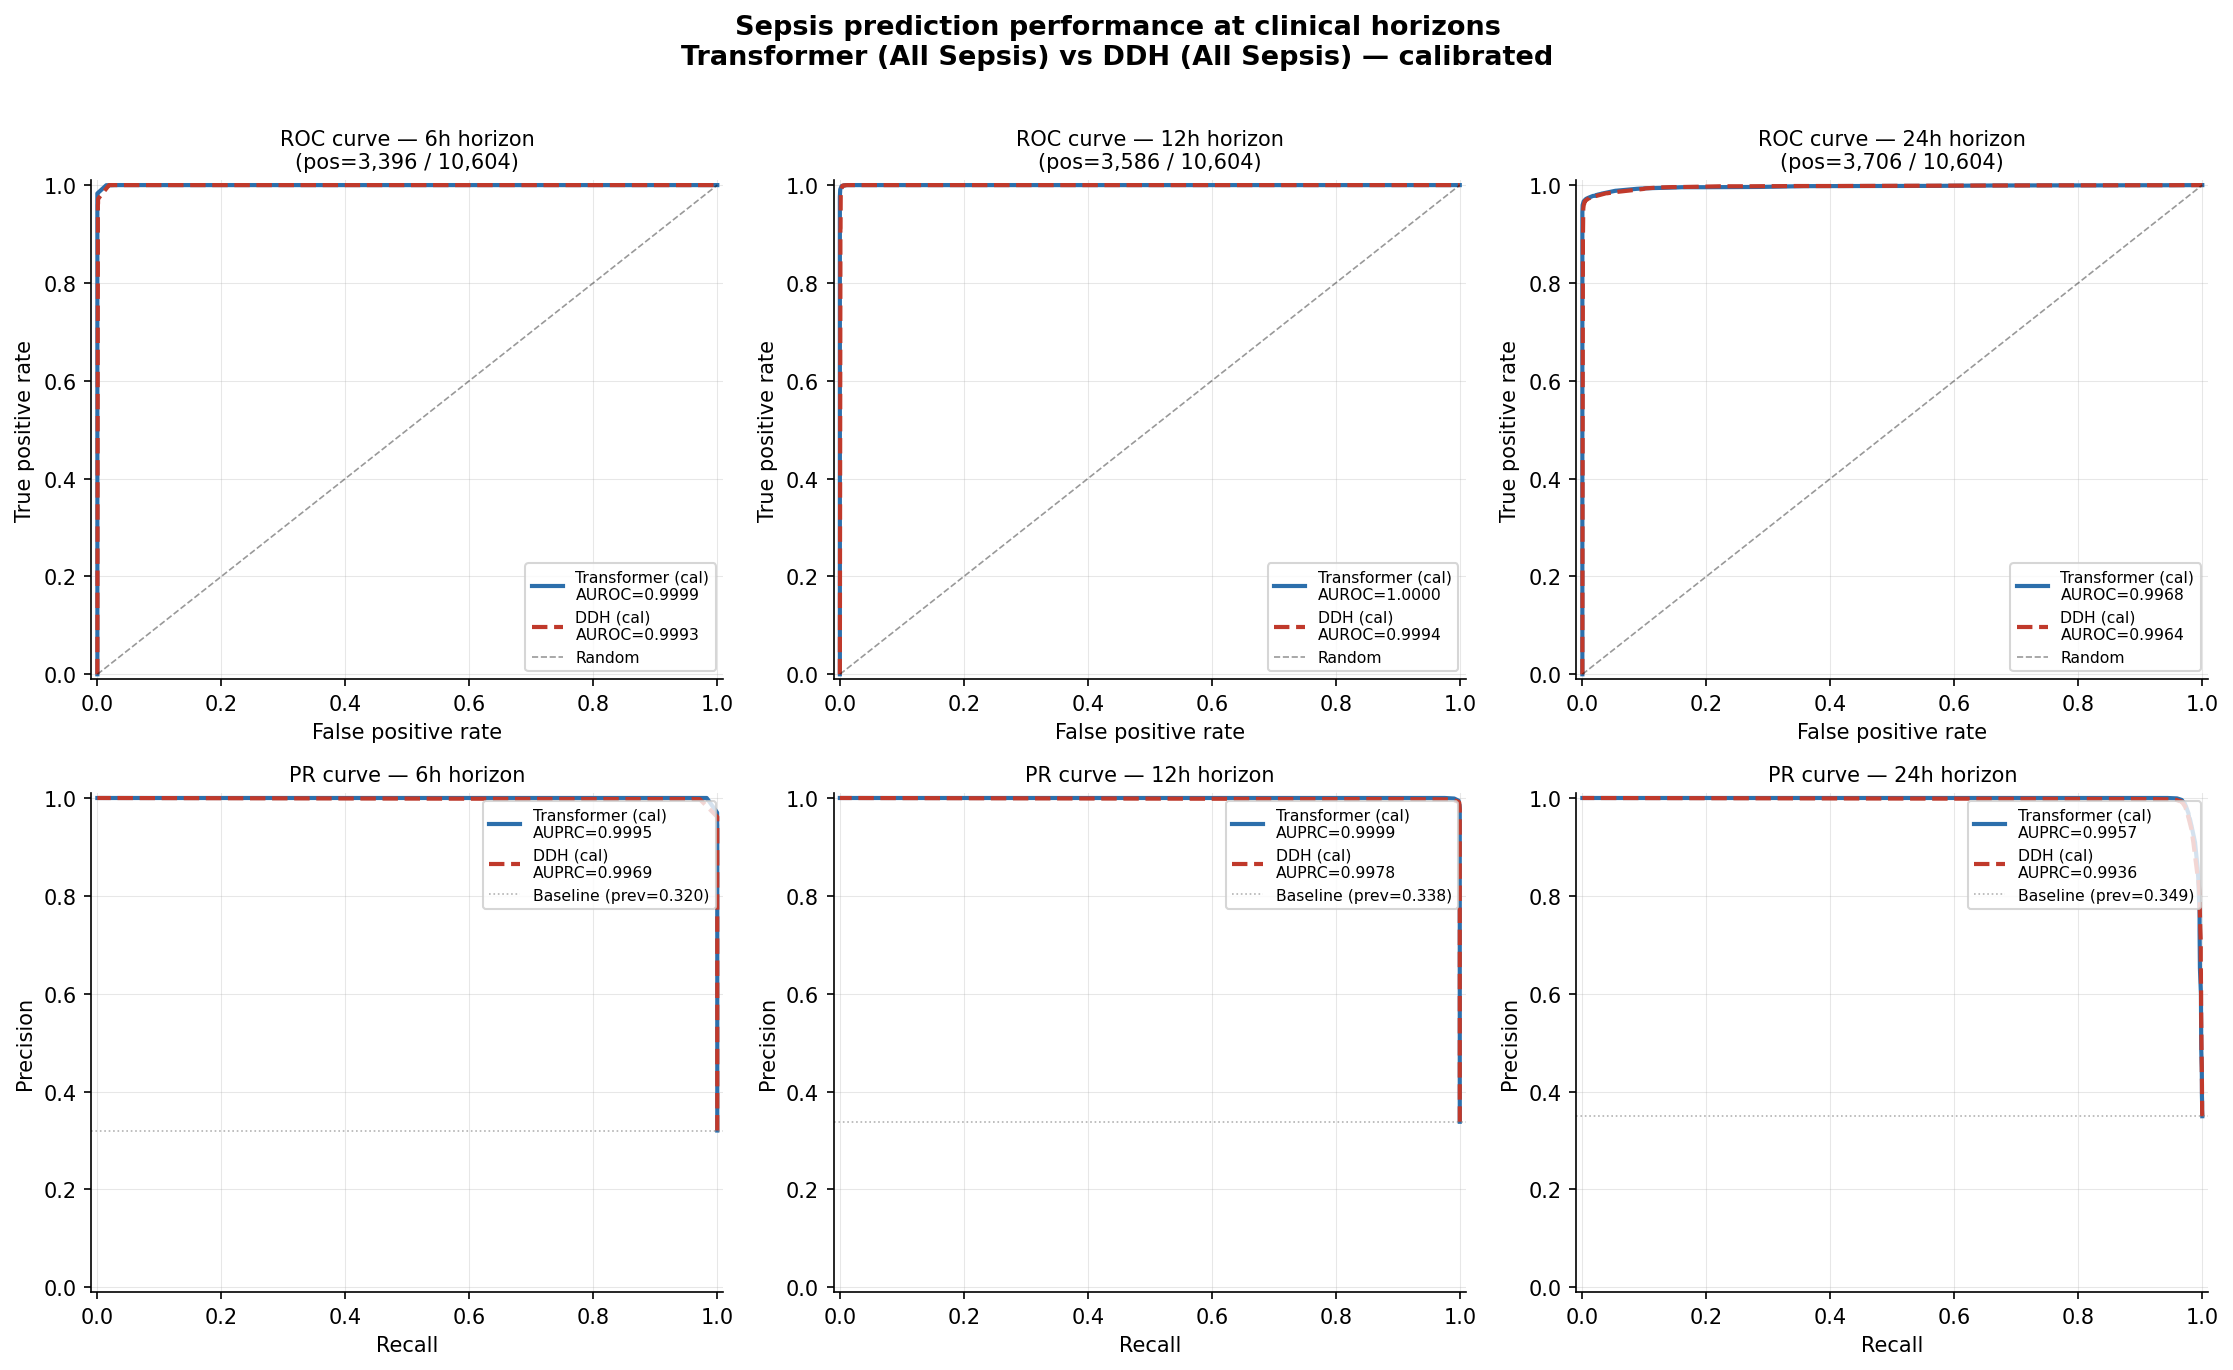

Saved → fig1_roc_pr_curves.png ✓


In [10]:
# ============================================================
# Cell 3a: Publication-quality ROC and PR curves
# Primary: Transformer All Sepsis
# Comparison: DDH All Sepsis
# Horizons: 6h, 12h, 24h
# ============================================================
from sklearn.metrics import (roc_curve, roc_auc_score,
                              precision_recall_curve,
                              average_precision_score)

print("Building ROC / PR curves...")

COLORS = {
    'Transformer (cal)': '#2C6FAC',
    'DDH (cal)'        : '#C0392B',
}
LINESTYLES = {
    'Transformer (cal)': '-',
    'DDH (cal)'        : '--',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    'Sepsis prediction performance at clinical horizons\n'
    'Transformer (All Sepsis) vs DDH (All Sepsis) — calibrated',
    fontsize=13, fontweight='bold', y=1.01
)

model_configs = [
    ('Transformer (cal)', surv_t_all,   dur_t_all,   evt_t_all),
    ('DDH (cal)',         surv_ddh_all, dur_ddh_all, evt_ddh_all),
]

for col_idx, H in enumerate(HORIZONS):
    ax_roc = axes[0, col_idx]
    ax_pr  = axes[1, col_idx]

    bin_H = int(np.clip(
        np.searchsorted(time_cuts, H, 'right'), 0, NUM_BINS - 1
    ))

    for model_name, surv, dur, evt in model_configs:
        y_true  = ((evt == 1) & (dur <= H)).astype(int)
        y_score = (1 - surv[:, bin_H]).clip(0, 1)
        n_pos   = y_true.sum()

        if n_pos < 5:
            continue

        color = COLORS[model_name]
        ls    = LINESTYLES[model_name]
        auroc = roc_auc_score(y_true, y_score)
        auprc = average_precision_score(y_true, y_score)

        # ROC
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ax_roc.plot(fpr, tpr, color=color, ls=ls, lw=2,
                    label=f'{model_name}\nAUROC={auroc:.4f}')

        # PR
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        baseline      = y_true.mean()
        ax_pr.plot(rec, prec, color=color, ls=ls, lw=2,
                   label=f'{model_name}\nAUPRC={auprc:.4f}')

    # ROC formatting
    ax_roc.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.4, label='Random')
    ax_roc.set_xlim(-0.01, 1.01); ax_roc.set_ylim(-0.01, 1.01)
    ax_roc.set_xlabel('False positive rate', fontsize=10)
    ax_roc.set_ylabel('True positive rate', fontsize=10)
    ax_roc.set_title(f'ROC curve — {H}h horizon\n'
                     f'(pos={y_true.sum():,} / {len(y_true):,})',
                     fontsize=10)
    ax_roc.legend(fontsize=7.5, loc='lower right')

    # PR formatting
    ax_pr.axhline(baseline, color='gray', lw=0.8, ls=':', alpha=0.6,
                  label=f'Baseline (prev={baseline:.3f})')
    ax_pr.set_xlim(-0.01, 1.01); ax_pr.set_ylim(-0.01, 1.01)
    ax_pr.set_xlabel('Recall', fontsize=10)
    ax_pr.set_ylabel('Precision', fontsize=10)
    ax_pr.set_title(f'PR curve — {H}h horizon', fontsize=10)
    ax_pr.legend(fontsize=7.5, loc='upper right')

plt.tight_layout()
fpath = FIG_DIR / 'fig1_roc_pr_curves.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {fpath.name} ✓")

Building survival & calibration figures...


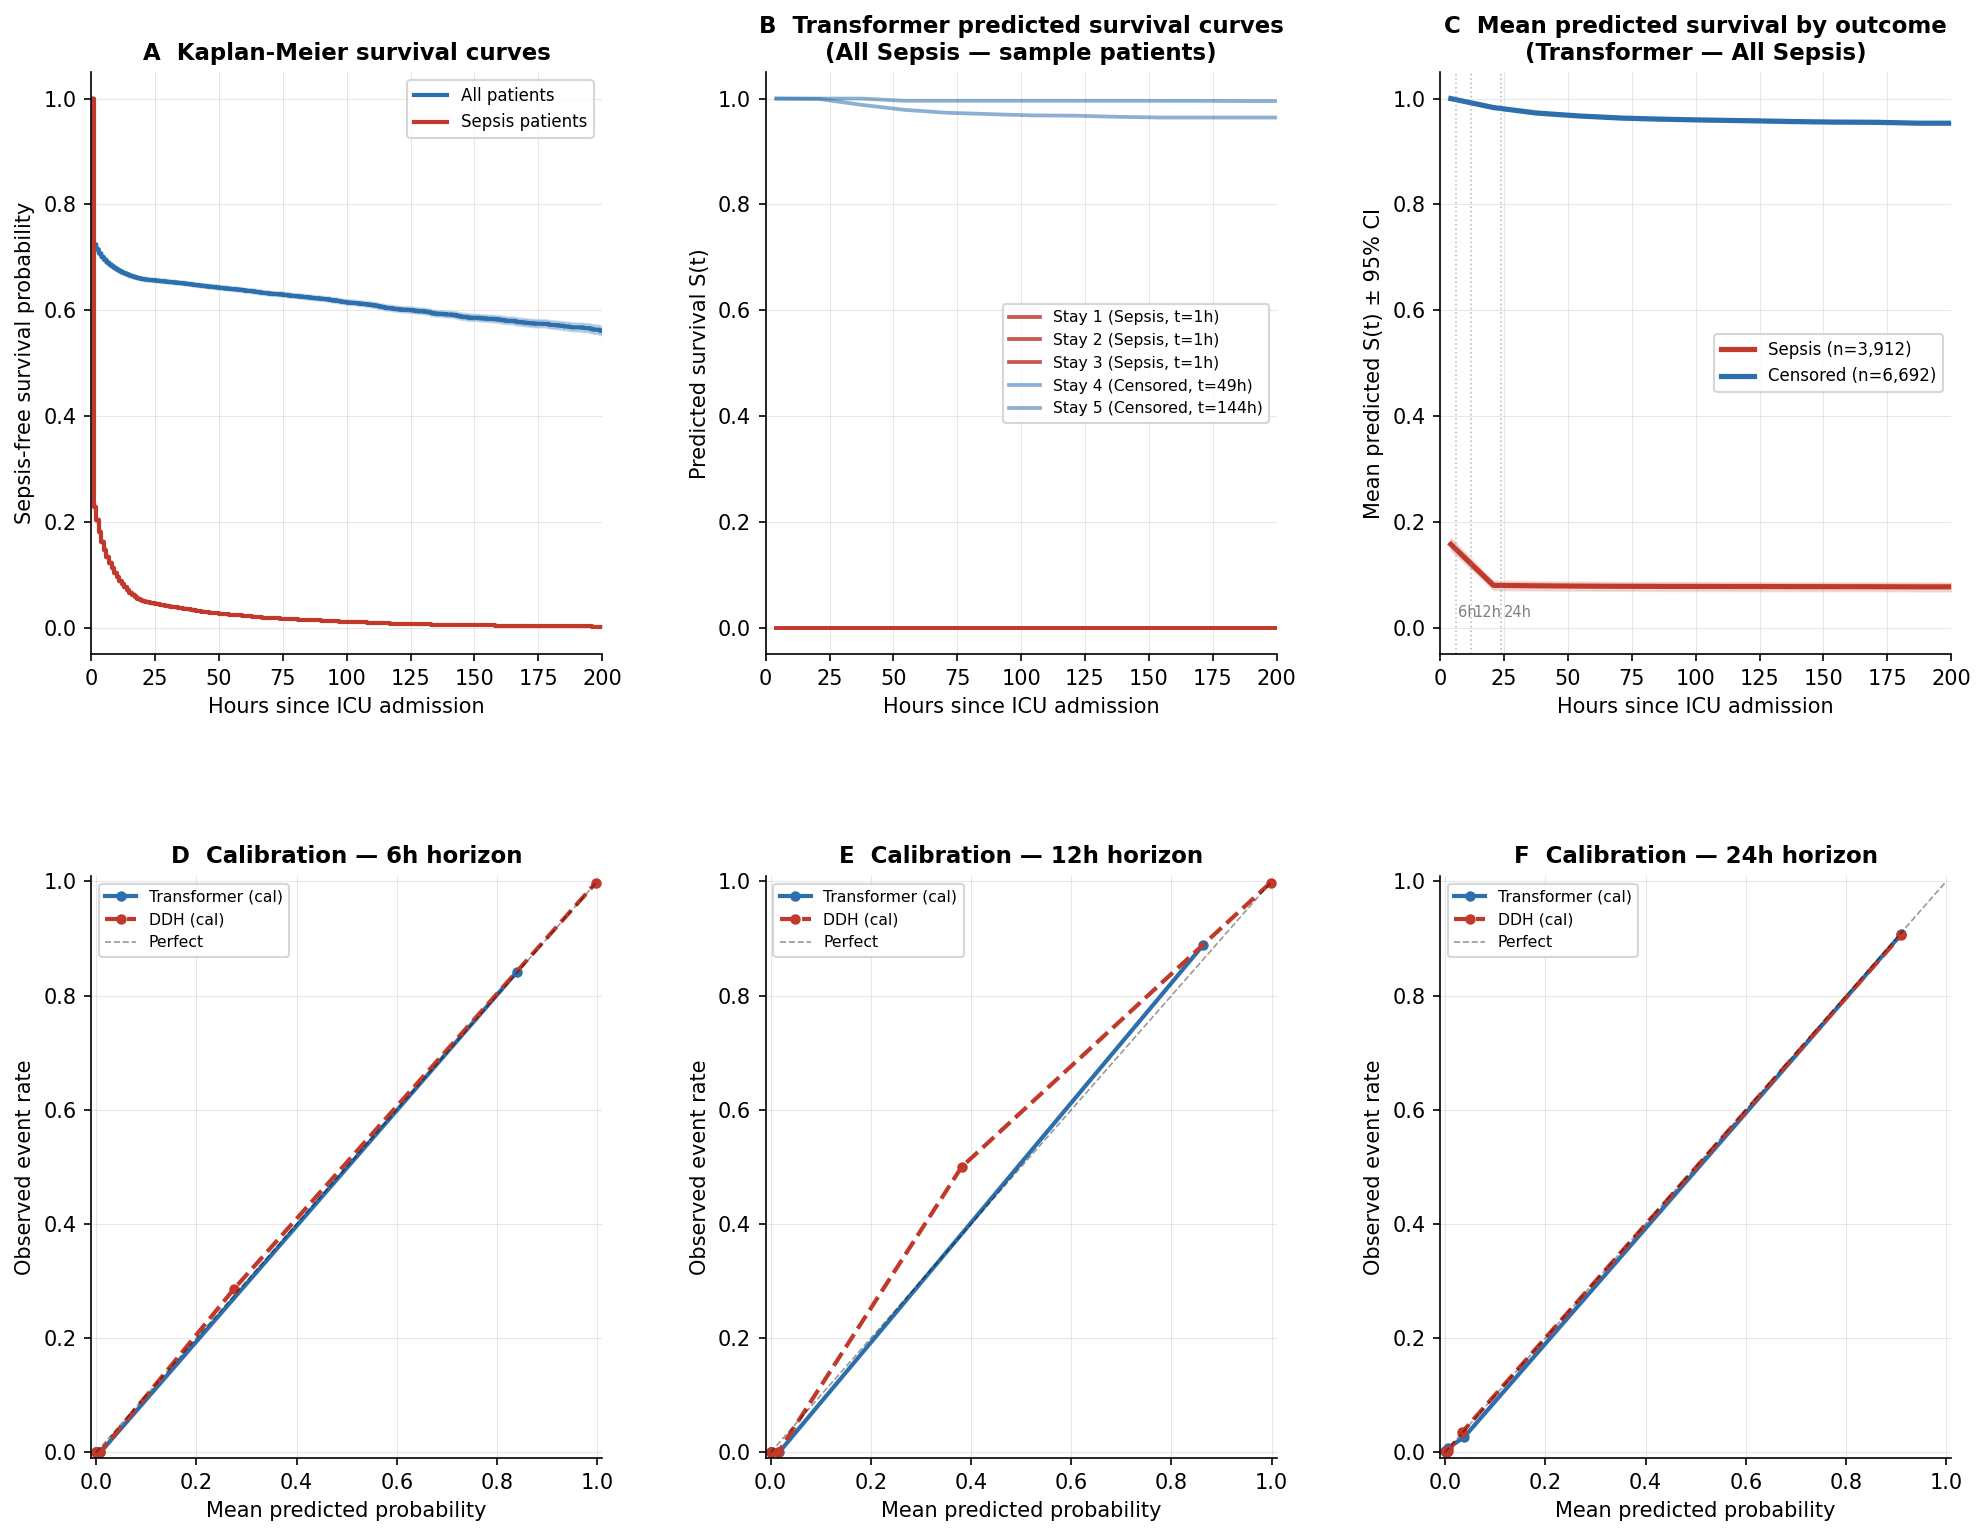

Saved → fig2_survival_calibration.png ✓


In [12]:
# ============================================================
# Cell 3b: Kaplan-Meier + predicted survival curves
#          + calibration plots
# ============================================================
from lifelines import KaplanMeierFitter

print("Building survival & calibration figures...")

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# ── Panel A: KM curves — All Sepsis dataset ───────────────────
ax_km = fig.add_subplot(gs[0, 0])

kmf_all = KaplanMeierFitter()
kmf_all.fit(survival_df['duration'],
            event_observed=survival_df['event'],
            label='All patients')
kmf_all.plot_survival_function(ax=ax_km, color='#2C6FAC', lw=2, ci_show=True)

kmf_sep = KaplanMeierFitter()
sep_mask = survival_df['event'] == 1
kmf_sep.fit(survival_df.loc[sep_mask, 'duration'],
            event_observed=survival_df.loc[sep_mask, 'event'],
            label='Sepsis patients')
kmf_sep.plot_survival_function(ax=ax_km, color='#C0392B', lw=2, ci_show=True)

ax_km.set_xlabel('Hours since ICU admission', fontsize=10)
ax_km.set_ylabel('Sepsis-free survival probability', fontsize=10)
ax_km.set_title('A  Kaplan-Meier survival curves', fontsize=11, fontweight='bold')
ax_km.set_xlim(0, 200)
ax_km.legend(fontsize=8)

# ── Panel B: Predicted survival curves — sample patients ──────
ax_surv = fig.add_subplot(gs[0, 1])

# Pick 3 sepsis + 2 censored from All Sepsis test set
sep_idx = np.where(evt_t_all == 1)[0][:3]
cen_idx = np.where(evt_t_all == 0)[0][:2]
sample  = np.concatenate([sep_idx, cen_idx])

for i, idx in enumerate(sample):
    label  = 'Sepsis' if evt_t_all[idx] == 1 else 'Censored'
    color  = '#C0392B' if evt_t_all[idx] == 1 else '#2C6FAC'
    alpha  = 0.85 if evt_t_all[idx] == 1 else 0.55
    ax_surv.plot(time_cuts, surv_t_all[idx],
                 color=color, alpha=alpha, lw=1.8,
                 label=f'Stay {i+1} ({label}, t={dur_t_all[idx]:.0f}h)')

ax_surv.set_xlabel('Hours since ICU admission', fontsize=10)
ax_surv.set_ylabel('Predicted survival S(t)', fontsize=10)
ax_surv.set_title('B  Transformer predicted survival curves\n(All Sepsis — sample patients)',
                  fontsize=11, fontweight='bold')
ax_surv.set_xlim(0, 200); ax_surv.set_ylim(-0.05, 1.05)
ax_surv.legend(fontsize=7.5)

# ── Panel C: Mean predicted survival by event group ───────────
ax_mean = fig.add_subplot(gs[0, 2])

mean_surv_sep = surv_t_all[evt_t_all == 1].mean(axis=0)
mean_surv_cen = surv_t_all[evt_t_all == 0].mean(axis=0)
ci_sep  = 1.96 * surv_t_all[evt_t_all == 1].std(axis=0) / np.sqrt((evt_t_all==1).sum())
ci_cen  = 1.96 * surv_t_all[evt_t_all == 0].std(axis=0) / np.sqrt((evt_t_all==0).sum())

ax_mean.plot(time_cuts, mean_surv_sep, color='#C0392B', lw=2.5,
             label=f'Sepsis (n={int(evt_t_all.sum()):,})')
ax_mean.fill_between(time_cuts,
                     mean_surv_sep - ci_sep,
                     mean_surv_sep + ci_sep,
                     color='#C0392B', alpha=0.15)

ax_mean.plot(time_cuts, mean_surv_cen, color='#2C6FAC', lw=2.5,
             label=f'Censored (n={(evt_t_all==0).sum():,})')
ax_mean.fill_between(time_cuts,
                     mean_surv_cen - ci_cen,
                     mean_surv_cen + ci_cen,
                     color='#2C6FAC', alpha=0.15)

for H in HORIZONS:
    ax_mean.axvline(H, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax_mean.text(H+1, 0.02, f'{H}h', fontsize=7, color='gray')

ax_mean.set_xlabel('Hours since ICU admission', fontsize=10)
ax_mean.set_ylabel('Mean predicted S(t) ± 95% CI', fontsize=10)
ax_mean.set_title('C  Mean predicted survival by outcome\n(Transformer — All Sepsis)',
                  fontsize=11, fontweight='bold')
ax_mean.set_xlim(0, 200); ax_mean.set_ylim(-0.05, 1.05)
ax_mean.legend(fontsize=8)

# ── Panels D-F: Calibration curves at 6h, 12h, 24h ───────────
from sklearn.calibration import calibration_curve

for col_idx, H in enumerate(HORIZONS):
    ax_cal = fig.add_subplot(gs[1, col_idx])

    bin_H = int(np.clip(np.searchsorted(time_cuts, H, 'right'), 0, NUM_BINS - 1))

    for model_name, surv, dur, evt in model_configs:
        y_true  = ((evt == 1) & (dur <= H)).astype(int)
        y_score = (1 - surv[:, bin_H]).clip(0, 1)

        if y_true.sum() < 10:
            continue

        frac, mean_pred = calibration_curve(
            y_true, y_score, n_bins=10, strategy='quantile'
        )
        color = COLORS[model_name]
        ls    = LINESTYLES[model_name]
        ax_cal.plot(mean_pred, frac, color=color, ls=ls, lw=2,
                    marker='o', ms=4, label=model_name)

    ax_cal.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.4, label='Perfect')
    ax_cal.set_xlabel('Mean predicted probability', fontsize=10)
    ax_cal.set_ylabel('Observed event rate', fontsize=10)
    ax_cal.set_title(f'{"DEF"[col_idx]}  Calibration — {H}h horizon',
                     fontsize=11, fontweight='bold')
    ax_cal.legend(fontsize=7.5)
    ax_cal.set_xlim(-0.01, 1.01); ax_cal.set_ylim(-0.01, 1.01)

fpath = FIG_DIR / 'fig2_survival_calibration.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {fpath.name} ✓")

Building forest plot...


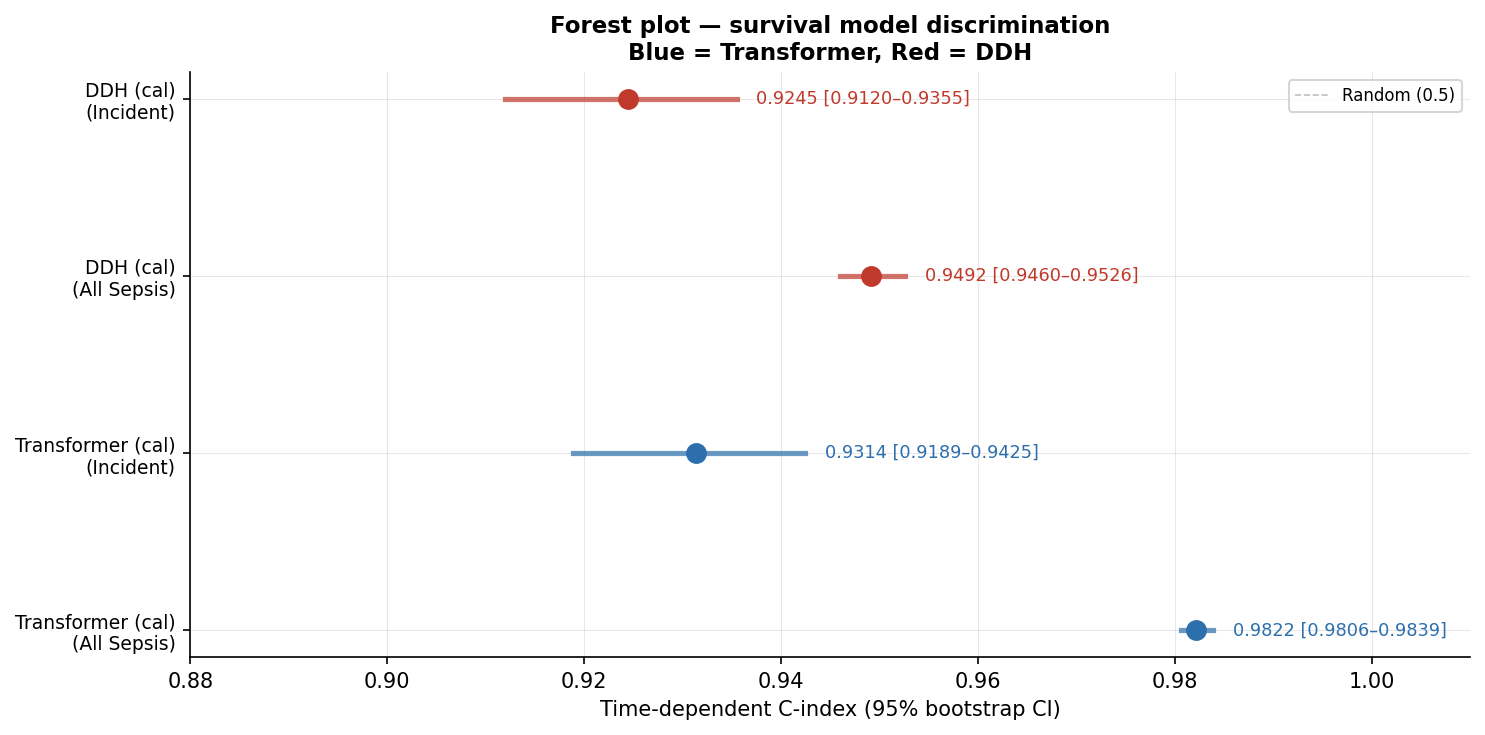

Saved → fig3_forest_plot.png ✓

Section 3 complete ✓  — ready for Section 4: Clinical threshold analysis


In [13]:
# ============================================================
# Cell 3c: Forest plot — C-index with 95% bootstrap CIs
# ============================================================
print("Building forest plot...")

fig, ax = plt.subplots(figsize=(10, 5))

models_ordered = bootstrap_df.copy()
models_ordered['Label'] = (models_ordered['Model'] + '\n('
                           + models_ordered['Dataset'] + ')')
models_ordered = models_ordered.iloc[::-1].reset_index(drop=True)

colors_fp = ['#2C6FAC' if 'Transformer' in r['Model'] else '#C0392B'
             for _, r in models_ordered.iterrows()]

for i, (_, row) in enumerate(models_ordered.iterrows()):
    color = colors_fp[i]
    ax.plot(row['C-index'], i, 'o', color=color, ms=9, zorder=3)
    ax.plot([row['CI_lo'], row['CI_hi']], [i, i],
            color=color, lw=2.5, alpha=0.7, zorder=2)
    ax.text(row['CI_hi'] + 0.002, i,
            f"{row['C-index']:.4f} [{row['CI_lo']:.4f}–{row['CI_hi']:.4f}]",
            va='center', fontsize=8.5, color=color)

ax.set_yticks(range(len(models_ordered)))
ax.set_yticklabels(models_ordered['Label'], fontsize=9)
ax.axvline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5, label='Random (0.5)')
ax.set_xlabel('Time-dependent C-index (95% bootstrap CI)', fontsize=10)
ax.set_title('Forest plot — survival model discrimination\n'
             'Blue = Transformer, Red = DDH', fontsize=11, fontweight='bold')
ax.set_xlim(0.88, 1.01)
ax.legend(fontsize=8)
plt.tight_layout()

fpath = FIG_DIR / 'fig3_forest_plot.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {fpath.name} ✓")
print("\nSection 3 complete ✓  — ready for Section 4: Clinical threshold analysis")

## Clinical Threshold analysis 

In [14]:
# ============================================================
# Cell 4a: Clinical threshold analysis
# Sensitivity, specificity, PPV, NPV across all thresholds
# Primary model: Transformer (All Sepsis) at 12h horizon
# ============================================================
from sklearn.metrics import confusion_matrix

print("Computing clinical threshold analysis...")

HERO_HORIZON = 12
bin_H = int(np.clip(
    np.searchsorted(time_cuts, HERO_HORIZON, 'right'), 0, NUM_BINS - 1
))

y_true  = ((evt_t_all == 1) & (dur_t_all <= HERO_HORIZON)).astype(int)
y_score = (1 - surv_t_all[:, bin_H]).clip(0, 1)

n_pos = y_true.sum()
n_neg = (y_true == 0).sum()
prev  = y_true.mean()

print(f"Horizon         : {HERO_HORIZON}h")
print(f"Positive cases  : {n_pos:,} / {len(y_true):,} ({prev:.3%})")

# ── Compute metrics across thresholds ─────────────────────────
thresholds = np.linspace(0.001, 0.999, 500)
rows_thresh = []

for t in thresholds:
    y_pred = (y_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    sens  = tp / (tp + fn + 1e-9)
    spec  = tn / (tn + fp + 1e-9)
    ppv   = tp / (tp + fp + 1e-9)
    npv   = tn / (tn + fn + 1e-9)
    f1    = 2 * tp / (2*tp + fp + fn + 1e-9)
    youden= sens + spec - 1
    n_alert = int(tp + fp)       # total patients flagged

    rows_thresh.append({
        'threshold': round(t, 4),
        'sensitivity': round(sens, 4),
        'specificity': round(spec, 4),
        'PPV'        : round(ppv, 4),
        'NPV'        : round(npv, 4),
        'F1'         : round(f1, 4),
        'Youden_J'   : round(youden, 4),
        'n_alerts'   : n_alert,
        'alert_rate' : round(n_alert / len(y_true), 4),
    })

thresh_df = pd.DataFrame(rows_thresh)

# ── Find key operating points ─────────────────────────────────
# 1. Youden's J (maximises sensitivity + specificity)
idx_youden = thresh_df['Youden_J'].idxmax()
op_youden  = thresh_df.loc[idx_youden]

# 2. F1-optimal
idx_f1 = thresh_df['F1'].idxmax()
op_f1  = thresh_df.loc[idx_f1]

# 3. Clinical constraint: sensitivity >= 0.95 (don't miss cases)
high_sens = thresh_df[thresh_df['sensitivity'] >= 0.95]
op_95sens = high_sens.loc[high_sens['specificity'].idxmax()]

# 4. Clinical constraint: specificity >= 0.95 (low false alarm rate)
high_spec = thresh_df[thresh_df['specificity'] >= 0.95]
op_95spec = high_spec.loc[high_spec['sensitivity'].idxmax()]

operating_points = {
    'Youden J'       : op_youden,
    'F1-optimal'     : op_f1,
    'Sens ≥ 0.95'    : op_95sens,
    'Spec ≥ 0.95'    : op_95spec,
}

print(f"\n{'Operating point':<18} {'Thresh':>7} {'Sens':>7} "
      f"{'Spec':>7} {'PPV':>7} {'NPV':>7} {'F1':>7} {'Alerts/1k':>10}")
print("-" * 75)
for name, op in operating_points.items():
    alerts_per_1k = op['alert_rate'] * 1000
    print(f"{name:<18} {op['threshold']:>7.3f} {op['sensitivity']:>7.4f} "
          f"{op['specificity']:>7.4f} {op['PPV']:>7.4f} {op['NPV']:>7.4f} "
          f"{op['F1']:>7.4f} {alerts_per_1k:>10.1f}")

thresh_df.to_csv(str(OUTPUT_DIR / 'threshold_analysis.csv'), index=False)
print(f"\nSaved → threshold_analysis.csv ✓")

Computing clinical threshold analysis...
Horizon         : 12h
Positive cases  : 3,586 / 10,604 (33.817%)

Operating point     Thresh    Sens    Spec     PPV     NPV      F1  Alerts/1k
---------------------------------------------------------------------------
Youden J             0.217  0.9980  0.9972  0.9944  0.9990  0.9962      339.4
F1-optimal           0.217  0.9980  0.9972  0.9944  0.9990  0.9962      339.4
Sens ≥ 0.95          0.493  0.9757  1.0000  1.0000  0.9878  0.9877      330.0
Spec ≥ 0.95          0.063  1.0000  0.9595  0.9266  1.0000  0.9619      365.0

Saved → threshold_analysis.csv ✓


Building threshold figure...


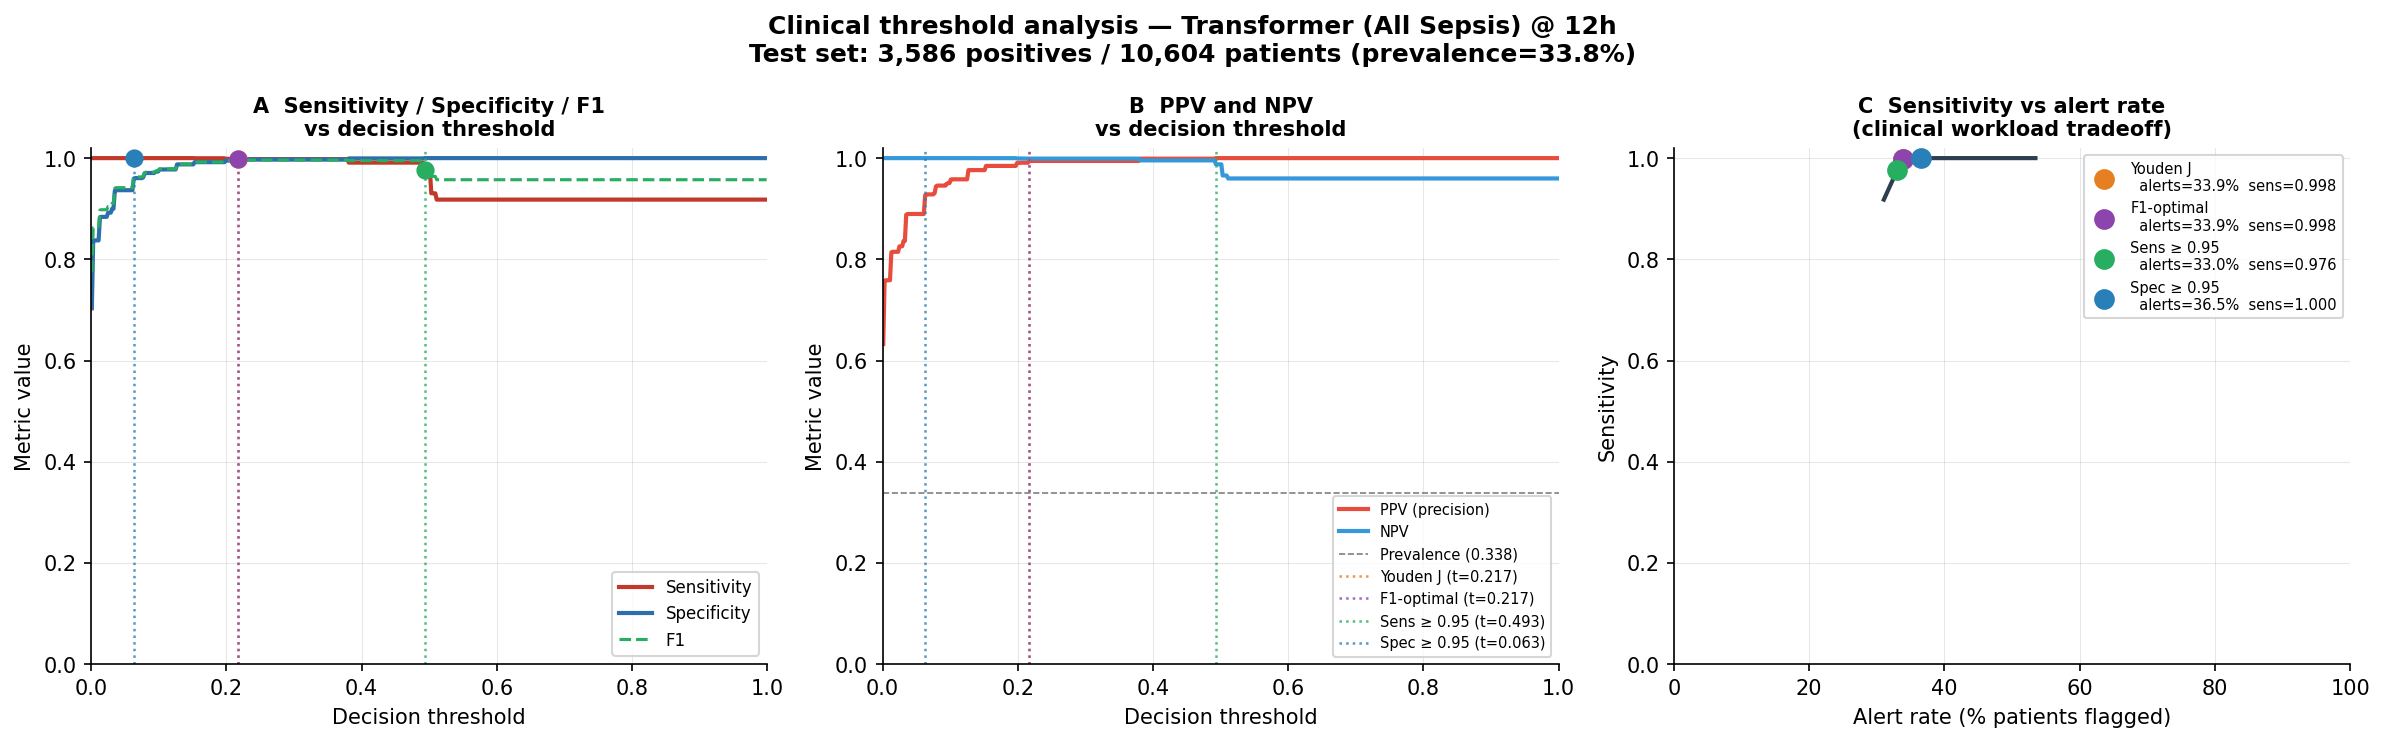

Saved → fig4_threshold_analysis.png ✓


In [15]:
# ============================================================
# Cell 4b: Clinical threshold figure
# ============================================================
print("Building threshold figure...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Clinical threshold analysis — Transformer (All Sepsis) @ {HERO_HORIZON}h\n'
    f'Test set: {n_pos:,} positives / {len(y_true):,} patients (prevalence={prev:.1%})',
    fontsize=12, fontweight='bold'
)

op_colors = {
    'Youden J'   : '#E67E22',
    'F1-optimal' : '#8E44AD',
    'Sens ≥ 0.95': '#27AE60',
    'Spec ≥ 0.95': '#2980B9',
}

# ── Panel A: Sensitivity & Specificity vs threshold ───────────
ax = axes[0]
ax.plot(thresh_df['threshold'], thresh_df['sensitivity'],
        color='#C0392B', lw=2, label='Sensitivity')
ax.plot(thresh_df['threshold'], thresh_df['specificity'],
        color='#2C6FAC', lw=2, label='Specificity')
ax.plot(thresh_df['threshold'], thresh_df['F1'],
        color='#27AE60', lw=1.5, ls='--', label='F1')

for name, op in operating_points.items():
    ax.axvline(op['threshold'], color=op_colors[name],
               lw=1.2, ls=':', alpha=0.8)
    ax.scatter(op['threshold'], op['sensitivity'],
               color=op_colors[name], s=60, zorder=5)

ax.set_xlabel('Decision threshold', fontsize=10)
ax.set_ylabel('Metric value', fontsize=10)
ax.set_title('A  Sensitivity / Specificity / F1\nvs decision threshold',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# ── Panel B: PPV & NPV vs threshold ───────────────────────────
ax = axes[1]
ax.plot(thresh_df['threshold'], thresh_df['PPV'],
        color='#E74C3C', lw=2, label='PPV (precision)')
ax.plot(thresh_df['threshold'], thresh_df['NPV'],
        color='#3498DB', lw=2, label='NPV')
ax.axhline(prev, color='gray', lw=0.8, ls='--',
           label=f'Prevalence ({prev:.3f})')

for name, op in operating_points.items():
    ax.axvline(op['threshold'], color=op_colors[name],
               lw=1.2, ls=':', alpha=0.8, label=f'{name} (t={op["threshold"]:.3f})')

ax.set_xlabel('Decision threshold', fontsize=10)
ax.set_ylabel('Metric value', fontsize=10)
ax.set_title('B  PPV and NPV\nvs decision threshold',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=7, ncol=1)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# ── Panel C: Alert rate vs sensitivity (workload tradeoff) ────
ax = axes[2]
ax.plot(thresh_df['alert_rate'] * 100,
        thresh_df['sensitivity'],
        color='#2C3E50', lw=2)

for name, op in operating_points.items():
    ax.scatter(op['alert_rate'] * 100, op['sensitivity'],
               color=op_colors[name], s=80, zorder=5,
               label=f"{name}\n  alerts={op['alert_rate']*100:.1f}%  "
                     f"sens={op['sensitivity']:.3f}")

ax.set_xlabel('Alert rate (% patients flagged)', fontsize=10)
ax.set_ylabel('Sensitivity', fontsize=10)
ax.set_title('C  Sensitivity vs alert rate\n(clinical workload tradeoff)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=7)
ax.set_xlim(0, 100); ax.set_ylim(0, 1.02)

plt.tight_layout()
fpath = FIG_DIR / 'fig4_threshold_analysis.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {fpath.name} ✓")

Computing decision curve analysis...


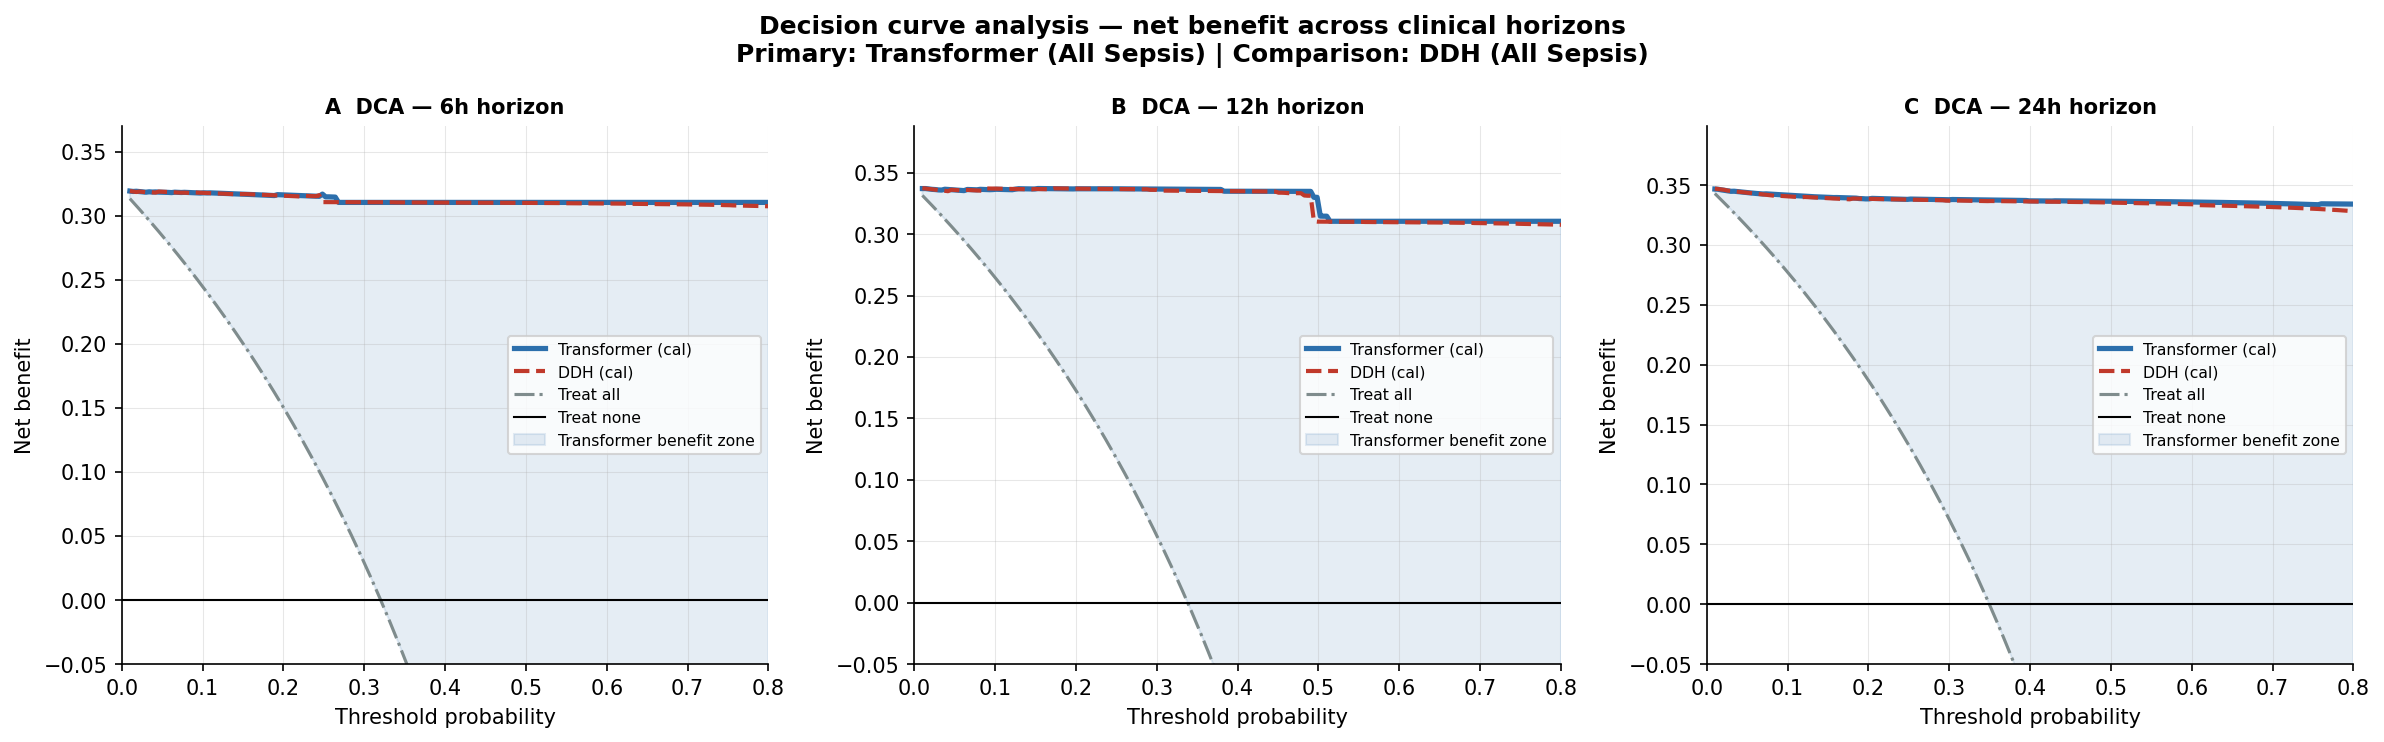

Saved → fig5_decision_curves.png ✓

Section 4 complete ✓
Ready for Section 5: SHAP explainability figures


In [16]:
# ============================================================
# Cell 4c: Decision Curve Analysis (DCA)
# Net benefit vs treat-all / treat-none across horizons
# ============================================================
print("Computing decision curve analysis...")

def decision_curve(y_true, y_score, thresholds):
    """
    Net benefit = TPR - FPR * (pt / (1 - pt))
    where pt = threshold probability.
    Returns array of net benefit values.
    """
    n = len(y_true)
    nb = []
    for pt in thresholds:
        if pt >= 1:
            nb.append(np.nan); continue
        y_pred = (y_score >= pt).astype(int)
        tp = ((y_pred == 1) & (y_true == 1)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        net_b = (tp / n) - (fp / n) * (pt / (1 - pt))
        nb.append(net_b)
    return np.array(nb)

def treat_all_nb(y_true, thresholds):
    prev = y_true.mean()
    return np.array([
        prev - (1 - prev) * (pt / (1 - pt + 1e-9))
        for pt in thresholds
    ])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Decision curve analysis — net benefit across clinical horizons\n'
    'Primary: Transformer (All Sepsis) | Comparison: DDH (All Sepsis)',
    fontsize=12, fontweight='bold'
)

dca_thresholds = np.linspace(0.01, 0.80, 200)

for col_idx, H in enumerate(HORIZONS):
    ax  = axes[col_idx]
    bH  = int(np.clip(np.searchsorted(time_cuts, H, 'right'), 0, NUM_BINS - 1))

    yt_t = ((evt_t_all   == 1) & (dur_t_all   <= H)).astype(int)
    ys_t = (1 - surv_t_all[:, bH]).clip(0, 1)

    yt_d = ((evt_ddh_all == 1) & (dur_ddh_all <= H)).astype(int)
    ys_d = (1 - surv_ddh_all[:, bH]).clip(0, 1)

    nb_t   = decision_curve(yt_t, ys_t, dca_thresholds)
    nb_d   = decision_curve(yt_d, ys_d, dca_thresholds)
    nb_all = treat_all_nb(yt_t, dca_thresholds)

    ax.plot(dca_thresholds, nb_t,
            color='#2C6FAC', lw=2.5, label='Transformer (cal)')
    ax.plot(dca_thresholds, nb_d,
            color='#C0392B', lw=2, ls='--', label='DDH (cal)')
    ax.plot(dca_thresholds, nb_all,
            color='#7F8C8D', lw=1.5, ls='-.', label='Treat all')
    ax.axhline(0, color='black', lw=1, label='Treat none')

    # Shade region where Transformer > treat-all
    mask = nb_t > nb_all
    ax.fill_between(dca_thresholds, nb_t, nb_all,
                    where=mask, alpha=0.12, color='#2C6FAC',
                    label='Transformer benefit zone')

    ax.set_xlabel('Threshold probability', fontsize=10)
    ax.set_ylabel('Net benefit', fontsize=10)
    ax.set_title(f'{"ABC"[col_idx]}  DCA — {H}h horizon',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5)
    ax.set_xlim(0, 0.80)
    ax.set_ylim(-0.05, yt_t.mean() + 0.05)

plt.tight_layout()
fpath = FIG_DIR / 'fig5_decision_curves.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {fpath.name} ✓")
print("\nSection 4 complete ✓")
print("Ready for Section 5: SHAP explainability figures")

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("C:/Users/20220505/Desktop/output path")

hl = pd.read_csv(str(OUTPUT_DIR / 'hourly_labels.csv'))
print(f"hourly_labels shape : {hl.shape}")
print(f"Columns : {list(hl.columns)}")
print(f"Max hour per stay (sample):")
print(hl.groupby('stay_id')['hour'].max().describe())
print(f"\nStays with hour > 24 : {(hl.groupby('stay_id')['hour'].max() > 24).sum():,}")
print(f"Stays with hour > 48 : {(hl.groupby('stay_id')['hour'].max() > 48).sum():,}")

hourly_labels shape : (2618839, 8)
Columns : ['stay_id', 'subject_id', 'hour', 'abs_time', 'sepsis_onset_time', 'hours_to_onset', 'label', 'split']
Max hour per stay (sample):
count    74550.000000
mean        35.128625
std         51.268723
min          1.000000
25%          5.000000
50%         21.000000
75%         45.000000
max       2644.000000
Name: hour, dtype: float64

Stays with hour > 24 : 32,621
Stays with hour > 48 : 16,390


In [20]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("C:/Users/20220505/Desktop/output path")

# ── Peek at vitals_complete ────────────────────────────────────
vc = pd.read_csv(str(OUTPUT_DIR / 'vitals_complete.csv'), nrows=5)
print("=== vitals_complete.csv ===")
print(f"Columns : {list(vc.columns)}")
print(vc.head())

# ── Check hour range ──────────────────────────────────────────
vc_full = pd.read_csv(str(OUTPUT_DIR / 'vitals_complete.csv'),
                      usecols=['stay_id', 'hour']
                      if 'hour' in pd.read_csv(
                          str(OUTPUT_DIR / 'vitals_complete.csv'),
                          nrows=1).columns
                      else ['stay_id'])
print(f"\nShape : {vc_full.shape}")
if 'hour' in vc_full.columns:
    print(f"Max hour : {vc_full['hour'].max()}")
    print(f"Stays with hour > 24 : {(vc_full.groupby('stay_id')['hour'].max() > 24).sum():,}")

# ── Peek at sofa_labs_hourly_wide ─────────────────────────────
sl = pd.read_csv(str(OUTPUT_DIR / 'sofa_labs_hourly_wide.csv'), nrows=3)
print("\n=== sofa_labs_hourly_wide.csv ===")
print(f"Columns : {list(sl.columns)}")
print(f"Shape preview: {sl.shape}")

=== vitals_complete.csv ===
Columns : ['hour', 'stay_id', 'abp_dia', 'abp_mean', 'abp_sys', 'heart_rate', 'resp_rate', 'spo2', 'temp_c']
   hour   stay_id  abp_dia  abp_mean  abp_sys  heart_rate  resp_rate   spo2  \
0     0  30000153     72.0      80.0    151.0       104.0       16.0  100.0   
1     1  30000153     61.0      80.0    131.0        83.0       16.0  100.0   
2     2  30000153     65.0      84.0    123.0        92.0       14.0  100.0   
3     3  30000153     55.0      71.0    109.0        83.0       16.0  100.0   
4     4  30000153     56.0      71.0    111.0       103.0       20.0  100.0   

   temp_c  
0     NaN  
1     NaN  
2     NaN  
3     NaN  
4     NaN  

Shape : (2137800, 2)
Max hour : 23
Stays with hour > 24 : 0

=== sofa_labs_hourly_wide.csv ===
Columns : ['stay_id', 'charttime_hour', 'bilirubin', 'creatinine', 'platelets']
Shape preview: (3, 5)


In [21]:
import pandas as pd
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("C:/Users/20220505/Desktop/output path")

# ── Check hourly_labels hour distribution more carefully ───────
hl = pd.read_csv(str(OUTPUT_DIR / 'hourly_labels.csv'))
print("=== hourly_labels hour range ===")
print(f"Total rows         : {len(hl):,}")
print(f"Unique stays       : {hl['stay_id'].nunique():,}")
print(f"Max hour overall   : {hl['hour'].max():.0f}")
print(f"Rows with hour > 24: {(hl['hour'] > 24).sum():,}")
print(f"Rows with hour > 48: {(hl['hour'] > 48).sum():,}")

# ── Check a long-stay patient ──────────────────────────────────
long_stay = hl.groupby('stay_id')['hour'].max().idxmax()
print(f"\nLongest stay in hourly_labels:")
print(hl[hl['stay_id'] == long_stay][['stay_id','hour','label']].head(10))
print(f"  stay_id={long_stay}, max_hour={hl[hl['stay_id']==long_stay]['hour'].max():.0f}")

# ── Check urine + vasopressors for hour range ──────────────────
uo = pd.read_csv(str(OUTPUT_DIR / 'urine_output_filtered.csv'), nrows=3)
print(f"\n=== urine_output_filtered.csv ===")
print(f"Columns: {list(uo.columns)}")

vp = pd.read_csv(str(OUTPUT_DIR / 'vasopressors_filtered.csv'), nrows=3)
print(f"\n=== vasopressors_filtered.csv ===")
print(f"Columns: {list(vp.columns)}")

el = pd.read_csv(str(OUTPUT_DIR / 'extra_labs_filtered.csv'), nrows=3)
print(f"\n=== extra_labs_filtered.csv ===")
print(f"Columns: {list(el.columns)}")

=== hourly_labels hour range ===
Total rows         : 2,618,839
Unique stays       : 74,550
Max hour overall   : 2644
Rows with hour > 24: 1,452,423
Rows with hour > 48: 872,220

Longest stay in hourly_labels:
          stay_id  hour  label
1856699  39667768     1      0
1856700  39667768     2      0
1856701  39667768     3      0
1856702  39667768     4      0
1856703  39667768     5      0
1856704  39667768     6      0
1856705  39667768     7      0
1856706  39667768     8      0
1856707  39667768     9      0
1856708  39667768    10      0
  stay_id=39667768, max_hour=2644

=== urine_output_filtered.csv ===
Columns: ['stay_id', 'charttime', 'itemid', 'value']

=== vasopressors_filtered.csv ===
Columns: ['stay_id', 'starttime', 'itemid', 'amount', 'rate', 'rateuom']

=== extra_labs_filtered.csv ===
Columns: ['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum', 'stay_id']


In [ ]:
# ============================================================
# 04_results_and_evaluation.ipynb
# Pure analysis notebook — no model training.
# Loads all outputs saved by 03b_survival_modeling.ipynb.
# ============================================================
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    calibration_curve,
)
from lifelines import KaplanMeierFitter
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = Path('/content/drive/MyDrive/mimic_iv_processed')
FIG_DIR    = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

HORIZONS  = [6, 12, 24]
NUM_BINS  = 48
MAX_HOURS = 200
time_cuts = np.linspace(0, MAX_HOURS, NUM_BINS + 1)[1:]

def savefig(name):
    plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {name}.png ✓")

print("Imports complete ✓")

In [ ]:
# ============================================================
# 04_results_and_evaluation.ipynb
# Pure analysis notebook — no model training.
# Loads all outputs saved by 03b_survival_modeling.ipynb.
# ============================================================
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    calibration_curve,
)
from lifelines import KaplanMeierFitter
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = Path('/content/drive/MyDrive/mimic_iv_processed')
FIG_DIR    = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

HORIZONS  = [6, 12, 24]
NUM_BINS  = 48
MAX_HOURS = 200
time_cuts = np.linspace(0, MAX_HOURS, NUM_BINS + 1)[1:]

def savefig(name):
    plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {name}.png ✓")

print("Imports complete ✓")

## 2. Canonical Results Table

In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("=" * 100)
print("COMPLETE RESULTS — Phase 2 Survival Modeling")
print("=" * 100)
print(results_df.to_string(index=False))
print()

# Best per metric per dataset
for dataset in ['Incident', 'All Sepsis']:
    sub = results_df[results_df['Dataset'] == dataset].copy()
    if sub.empty:
        continue
    print(f"── Best per metric ({dataset}) ─────────────────────────")
    print(f"  C-index : "
          f"{sub.loc[sub['C-index'].idxmax(), 'Model']} "
          f"({sub.loc[sub['C-index'].idxmax(), 'Stage']}) "
          f"→ {sub['C-index'].max():.4f}")
    print(f"  IBS     : "
          f"{sub.loc[sub['IBS'].idxmin(), 'Model']} "
          f"({sub.loc[sub['IBS'].idxmin(), 'Stage']}) "
          f"→ {sub['IBS'].min():.4f}")
    print()

## 3. Calibration Curves — All Models, Both Datasets

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Calibration Curves at Fixed Horizons\n'
    'Before vs After Isotonic Regression Calibration',
    fontsize=13, fontweight='bold'
)

configs = [
    ('DDH — Incident',     surv_ir,  surv_ic,  dur_i,  evt_i),
    ('DDH — All Sepsis',   surv_ar,  surv_ac,  dur_a,  evt_a),
    ('Transformer — Inc.', surv_tir, surv_tic, dur_ti, evt_ti),
]
check_horizons = [6, 24]

for col_idx, (label, surv_raw, surv_cal, durs, evts) in enumerate(configs):
    for row_idx, H in enumerate(check_horizons):
        ax     = axes[row_idx, col_idx]
        bin_H  = int(np.clip(
            np.searchsorted(time_cuts, H, side='right'),
            0, NUM_BINS - 1
        ))
        y_true = ((evts == 1) & (durs <= H)).astype(int)

        if y_true.sum() < 5:
            ax.text(0.5, 0.5, 'Insufficient events',
                    ha='center', va='center',
                    transform=ax.transAxes)
            continue

        for surv_arr, lbl, style, clr in [
            (surv_raw, 'Before cal', '--', 'tomato'),
            (surv_cal, 'After cal',  '-',  'steelblue'),
        ]:
            y_sc = (1 - surv_arr[:, bin_H]).clip(0, 1)
            frac, mean = calibration_curve(
                y_true, y_sc, n_bins=8, strategy='uniform'
            )
            ax.plot(mean, frac, style, color=clr,
                    lw=2, label=lbl)

        ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Perfect')
        ax.set_title(f'{label}\nt={H}h  (pos={y_true.sum():,})')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
savefig('calibration_all_models')

## 4. AUROC / AUPRC at Clinical Horizons

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'AUROC Comparison at Clinical Horizons\n'
    'All models — Incident Sepsis (calibrated)',
    fontsize=13, fontweight='bold'
)

model_labels = ['DeepSurv', 'DDH (calibrated)', 'Transformer (cal)']
bar_colors   = ['#607D8B', '#F44336', '#2196F3']
x = np.arange(len(model_labels))

for col_idx, H in enumerate(HORIZONS):
    ax   = axes[col_idx]
    vals = []
    for m in model_labels:
        key = f"{m}|Incident"
        if key in horizon_results:
            vals.append(horizon_results[key][H]['auroc'])
        else:
            vals.append(float('nan'))

    bars = ax.bar(x, vals, 0.6,
                  color=bar_colors, alpha=0.87)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{v:.3f}',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold'
            )

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels,
                       rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('AUROC')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'AUROC @ {H}h')
    ax.axhline(0.5, color='black', lw=1,
               ls='--', alpha=0.4, label='Random')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
savefig('auroc_comparison')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'ROC and PR Curves at Clinical Horizons\n'
    'DDH (calibrated) — Incident Sepsis',
    fontsize=13, fontweight='bold'
)

colors = {6: '#F44336', 12: '#FF9800', 24: '#2196F3'}

for col_idx, H in enumerate(HORIZONS):
    bin_H  = int(np.clip(
        np.searchsorted(time_cuts, H, side='right'),
        0, NUM_BINS - 1
    ))
    y_true  = ((evt_i == 1) & (dur_i <= H)).astype(int)
    y_score = (1 - surv_ic[:, bin_H]).clip(0, 1)

    if y_true.sum() < 5:
        for row in range(2):
            axes[row, col_idx].text(
                0.5, 0.5, 'Too few events',
                ha='center', va='center',
                transform=axes[row, col_idx].transAxes
            )
        continue

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auroc       = roc_auc_score(y_true, y_score)
    axes[0, col_idx].plot(fpr, tpr, color=colors[H],
                          lw=2.5,
                          label=f'AUROC={auroc:.3f}')
    axes[0, col_idx].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    axes[0, col_idx].set_xlabel('FPR')
    axes[0, col_idx].set_ylabel('TPR')
    axes[0, col_idx].set_title(
        f'ROC @ {H}h\n'
        f'(pos={y_true.sum():,}/{len(y_true):,})'
    )
    axes[0, col_idx].legend(fontsize=9)
    axes[0, col_idx].grid(alpha=0.3)

    # PR
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    auprc        = average_precision_score(y_true, y_score)
    baseline     = y_true.mean()
    axes[1, col_idx].plot(rec, prec, color=colors[H],
                          lw=2.5,
                          label=f'AUPRC={auprc:.3f}')
    axes[1, col_idx].axhline(
        baseline, color='gray', lw=1, ls='--',
        label=f'Baseline={baseline:.3f}'
    )
    axes[1, col_idx].set_xlabel('Recall')
    axes[1, col_idx].set_ylabel('Precision')
    axes[1, col_idx].set_title(f'PR @ {H}h')
    axes[1, col_idx].legend(fontsize=9)
    axes[1, col_idx].grid(alpha=0.3)

plt.tight_layout()
savefig('roc_pr_horizons')

## 5. Predicted Survival vs Kaplan-Meier

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Predicted Survival vs Kaplan-Meier\n'
    'Incident Sepsis — Test Set',
    fontsize=13, fontweight='bold'
)

for ax, title, surv_arr, durs, evts in [
    (axes[0], 'DDH (calibrated)',         surv_ic,  dur_i,  evt_i),
    (axes[1], 'Transformer (calibrated)', surv_tic, dur_ti, evt_ti),
]:
    # Kaplan-Meier
    kmf = KaplanMeierFitter()
    kmf.fit(durs, event_observed=evts,
            label='Kaplan-Meier (observed)')
    kmf.plot_survival_function(ax=ax, color='black',
                               lw=2.5, ci_show=True)

    # Mean predicted survival
    mean_surv = surv_arr.mean(axis=0)
    ax.plot(time_cuts, mean_surv,
            color='tomato', lw=2.5, ls='--',
            label='Mean predicted S(t)')

    # 10th–90th percentile band
    p10 = np.percentile(surv_arr, 10, axis=0)
    p90 = np.percentile(surv_arr, 90, axis=0)
    ax.fill_between(time_cuts, p10, p90,
                    alpha=0.15, color='tomato',
                    label='10th–90th pct')

    ax.set_xlabel('Hours since ICU admission')
    ax.set_ylabel('Survival probability (sepsis-free)')
    ax.set_title(title)
    ax.set_xlim(0, 150)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
savefig('survival_km_vs_model')

## 6. SpO2 Dominance — Diagnosis Figure

In [ ]:
# Load winsorised scaler and bounds
scaler_w = joblib.load(str(OUTPUT_DIR / 'survival_scaler_winsorised.pkl'))
lo2      = np.load(str(OUTPUT_DIR / 'winsor_lo.npy'))
hi2      = np.load(str(OUTPUT_DIR / 'winsor_hi.npy'))

# Load original scaler
scaler_orig = joblib.load(
    str(OUTPUT_DIR / 'survival_scaler_incident.pkl')
)

# Rebuild test features to compare variance
surv_inc_data = pd.read_csv(
    OUTPUT_DIR / 'survival_incident_dataset.csv'
)
all_features  = pd.read_csv(OUTPUT_DIR / 'engineered_features.csv')
test_ids      = surv_inc_data[
    surv_inc_data['split'] == 'test'
]['stay_id']
test_raw = all_features[
    all_features['stay_id'].isin(test_ids)
][feature_cols].fillna(0).values

X_orig = scaler_orig.transform(test_raw)
X_wsor = scaler_w.transform(np.clip(test_raw, lo2, hi2))

var_orig = X_orig.var(axis=0)
var_wsor = X_wsor.var(axis=0)

# SHAP importance
mabs_orig = np.abs(shap_values).mean(axis=(0, 2))
top15_orig = np.argsort(mabs_orig)[::-1][:15]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    'SpO2 Dominance — Diagnosis and Fix\n'
    'Left: original SHAP | '
    'Middle: variance comparison | '
    'Right: would update after winsorised SHAP re-run',
    fontsize=12, fontweight='bold'
)

# Original SHAP importance
spo2_mask = ['spo2' in feature_cols[i].lower()
             for i in top15_orig]
bar_colors_orig = ['tomato' if m else 'steelblue'
                   for m in spo2_mask]
axes[0].barh(
    range(15),
    mabs_orig[top15_orig][::-1],
    color=bar_colors_orig[::-1], alpha=0.85
)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(
    [feature_cols[i] for i in top15_orig][::-1], fontsize=8
)
axes[0].set_xlabel('Mean |SHAP|')
axes[0].set_title('Original SHAP\n(red = SpO2 features)')
axes[0].grid(axis='x', alpha=0.3)

# Variance before vs after
top15_var = np.argsort(var_orig)[::-1][:15]
x_pos     = np.arange(15)
axes[1].bar(x_pos - 0.2, var_orig[top15_var], 0.4,
            color='tomato', alpha=0.8, label='Original')
axes[1].bar(x_pos + 0.2, var_wsor[top15_var], 0.4,
            color='steelblue', alpha=0.8, label='Winsorised')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(
    [feature_cols[i] for i in top15_var],
    rotation=45, ha='right', fontsize=7
)
axes[1].set_ylabel('Scaled feature variance')
axes[1].set_title('Feature Variance\nBefore vs After Winsorisation')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Placeholder for winsorised SHAP
axes[2].text(
    0.5, 0.5,
    'Re-run SHAP on winsorised\nfeatures in 03b to populate\n'
    'this panel.\n\nExpected: SpO2 features\nno longer dominate.',
    ha='center', va='center',
    fontsize=11, color='gray',
    transform=axes[2].transAxes
)
axes[2].set_title('Winsorised SHAP\n(pending re-run)')
axes[2].grid(alpha=0.2)

plt.tight_layout()
savefig('spo2_dominance_diagnosis')

## 7. SurvSHAP(t) — Feature Importance

In [ ]:
mabs      = np.abs(shap_values).mean(axis=(0, 2))
top15_idx = np.argsort(mabs)[::-1][:15]
top15_names = [feature_cols[i] for i in top15_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'SurvSHAP(t) — Feature Importance\n'
    'Dynamic-DeepHit (Incident Sepsis)',
    fontsize=13, fontweight='bold'
)

# Bar chart
axes[0].barh(
    range(15),
    mabs[top15_idx][::-1],
    color=cm.RdYlGn(np.linspace(0.8, 0.2, 15))[::-1],
    alpha=0.87
)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top15_names[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP| (averaged over time points)')
axes[0].set_title('Top 15 Features — Overall Importance')
axes[0].grid(axis='x', alpha=0.3)

# Heatmap — importance over time
n_times         = shap_values.shape[2]
shap_time_top   = np.abs(shap_values).mean(axis=0)[top15_idx]
im = axes[1].imshow(
    shap_time_top, aspect='auto', cmap='YlOrRd'
)
axes[1].set_xticks(range(n_times))
axes[1].set_xticklabels(
    [f'{t:.0f}h' for t in shap_times],
    rotation=45, fontsize=7
)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top15_names, fontsize=8)
axes[1].set_xlabel('Hours since ICU admission')
axes[1].set_title('Importance Over Time')
plt.colorbar(im, ax=axes[1], label='Mean |SHAP|')

plt.tight_layout()
savefig('shap_importance')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'SurvSHAP(t) — Direction of Effect Over Time\n'
    'Positive = increases sepsis-free survival  |  '
    'Negative = increases sepsis risk',
    fontsize=12, fontweight='bold'
)

top5_idx    = top15_idx[:5]
palette     = ['#F44336','#2196F3','#4CAF50','#FF9800','#9C27B0']
signed_shap = shap_values.mean(axis=0)   # (n_features, n_times)

for i, (fi, clr) in enumerate(zip(top5_idx, palette)):
    label = feature_cols[fi]
    axes[0].plot(shap_times,
                 np.abs(shap_values[:, fi, :]).mean(axis=0),
                 color=clr, lw=2.5, marker='o', ms=5,
                 label=label)
    axes[1].plot(shap_times,
                 signed_shap[fi],
                 color=clr, lw=2.5, marker='o', ms=5,
                 label=label)

axes[0].set_xlabel('Hours since ICU admission')
axes[0].set_ylabel('Mean |SHAP|')
axes[0].set_title('Magnitude Over Time')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color='black', lw=1, ls='--', alpha=0.5)
axes[1].set_xlabel('Hours since ICU admission')
axes[1].set_ylabel('Mean SHAP')
axes[1].set_title('Direction Over Time')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
savefig('shap_direction')

## 8. Model Comparison Summary

In [ ]:
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.4, wspace=0.35)
fig.suptitle(
    'Phase 2 — Model Comparison Summary\n'
    'Incident Sepsis (primary) | All Sepsis (sensitivity)',
    fontsize=14, fontweight='bold'
)

model_order  = ['DeepSurv', 'DDH', 'Transformer']
colors_map   = {
    'DeepSurv'   : '#607D8B',
    'DDH'        : '#F44336',
    'Transformer': '#2196F3',
}
x = np.arange(len(model_order))

def bar_subplot(ax, metric, dataset, title, ylim=(0, 1)):
    vals = []
    for m in model_order:
        # Use calibrated stage where available
        sub = results_df[
            (results_df['Model'] == m) &
            (results_df['Dataset'] == dataset) &
            (results_df['Stage'].isin(['Calibrated', '—']))
        ]
        if len(sub) == 0:
            vals.append(0.0)
        else:
            vals.append(float(sub[metric].iloc[0])
                        if metric in sub.columns
                        else 0.0)

    bars = ax.bar(x, vals, 0.6,
                  color=[colors_map[m] for m in model_order],
                  alpha=0.87)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{v:.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )
    ax.set_xticks(x)
    ax.set_xticklabels(model_order,
                       rotation=15, ha='right', fontsize=9)
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

bar_subplot(fig.add_subplot(gs[0, 0]),
            'C-index', 'Incident',
            'C-index — Incident', (0.5, 1))
bar_subplot(fig.add_subplot(gs[0, 1]),
            'C-index', 'All Sepsis',
            'C-index — All Sepsis', (0.5, 1))
bar_subplot(fig.add_subplot(gs[0, 2]),
            'IBS', 'Incident',
            'IBS — Incident (lower is better)', (0, 0.3))
bar_subplot(fig.add_subplot(gs[1, 0]),
            'AUROC@6h', 'Incident',
            'AUROC@6h — Incident', (0.5, 1))
bar_subplot(fig.add_subplot(gs[1, 1]),
            'AUROC@12h', 'Incident',
            'AUROC@12h — Incident', (0.5, 1))
bar_subplot(fig.add_subplot(gs[1, 2]),
            'AUROC@24h', 'Incident',
            'AUROC@24h — Incident', (0.5, 1))

savefig('model_comparison_summary')

print("\n" + "=" * 60)
print("04_results_and_evaluation.ipynb COMPLETE")
print("=" * 60)
print(f"\nAll figures saved to: {FIG_DIR}")